### 1. Introducción a la Modulación OFDM

La **Modulación por División de Frecuencia Ortogonal (OFDM)** es una técnica de modulación digital multiportadora que divide un canal de banda ancha en un gran número de subcanales de banda estrecha, conocidos como **subportadoras**. La clave de OFDM reside en la **ortogonalidad** de estas subportadoras, lo que permite que sus espectros se solapen sin causar interferencia entre sí, logrando una alta eficiencia espectral.

Las principales ventajas que han convertido a OFDM en la base de estándares modernos como Wi-Fi (802.11a/g/n/ac/ax), LTE, 5G y DVB son:

*   **Robustez contra la Interferencia Intersimbólica (ISI):** Al transmitir datos en paralelo sobre muchas subportadoras lentas, la duración de cada símbolo se incrementa significativamente. Esto hace que el retardo del canal (multipath delay spread) sea una fracción pequeña de la duración del símbolo, mitigando la ISI.
*   **Eliminación de la ISI con el Prefijo Cíclico (CP):** Se introduce un intervalo de guarda (Guard Interval) antes de cada símbolo, usualmente una copia del final del propio símbolo (Prefijo Cíclico). Esto cumple dos funciones:
    1.  Absorbe la ISI del símbolo anterior, dejando la parte útil del símbolo actual intacta.
    2.  Convierte la convolución lineal del canal en una convolución circular, lo que simplifica enormemente la ecualización en el receptor.
*   **Eficiencia Computacional:** En lugar de utilizar un banco de moduladores y demoduladores analógicos (uno por subportadora), OFDM se implementa eficientemente en el dominio digital mediante la **Transformada Inversa Rápida de Fourier (IFFT)** en el transmisor y la **Transformada Rápida de Fourier (FFT)** en el receptor.
*   **Ecualización Sencilla:** Gracias al prefijo cíclico, el efecto de un canal selectivo en frecuencia se reduce a una simple multiplicación por un escalar complejo en cada subportadora. Esto permite una ecualización de un solo toque (one-tap equalizer) por subportadora, mucho más simple que los ecualizadores complejos necesarios en sistemas de portadora única.

### 2. Flujo de Transmisión y Recepción (Visión Ideal)

El proceso completo, desde los bits de entrada hasta los bits recuperados, sigue una serie de pasos bien definidos.

#### **Proceso del Transmisor OFDM:**

1.  **Generación de Bits:** Se crea una secuencia de bits binarios aleatorios como fuente de datos.
2.  **Mapeo de Símbolos:** Los bits se agrupan y se mapean a símbolos complejos de una constelación digital (ej. QPSK, 16-QAM). Para QPSK, se agrupan de 2 en 2.
3.  **Conversión Serie a Paralelo (S/P):** Los símbolos complejos se agrupan en bloques de tamaño `N`, donde `N` es el número de subportadoras. Cada bloque formará un símbolo OFDM.
4.  **Modulación IFFT:** Se aplica la IFFT a cada bloque de `N` símbolos. Esto transforma los datos del dominio de la frecuencia al dominio del tiempo, generando la señal multiportadora. La salida son `N` muestras de tiempo complejas.
5.  **Inserción del Prefijo Cíclico (CP):** Se copian las últimas `L` muestras de la salida de la IFFT y se anteponen al bloque. El símbolo OFDM ahora tiene `N + L` muestras.
6.  **Conversión Paralelo a Serie (P/S):** Los símbolos OFDM se concatenan para formar la trama de datos a transmitir.

#### **Proceso del Receptor OFDM:**

1.  **Sincronización y Conversión S/P:** El receptor se sincroniza con la trama recibida y la divide en bloques de `N + L` muestras.
2.  **Eliminación del Prefijo Cíclico:** Se descartan las primeras `L` muestras de cada bloque, eliminando el CP.
3.  **Demodulación FFT:** Se aplica la FFT a los `N` muestras restantes para transformar la señal de vuelta al dominio de la frecuencia. La salida son los `N` símbolos complejos recibidos en cada subportadora.
4.  **Ecualización (Opcional):** Se corrige la atenuación y el desfase introducidos por el canal (en un canal ideal, este paso es una identidad).
5.  **Demapeo de Símbolos:** Cada símbolo complejo recibido se decide al punto más cercano de la constelación original (detección de máxima verosimilitud).
6.  **Conversión Paralelo a Serie y Recuperación de Bits:** Los símbolos decididos se convierten de nuevo a bits, y estos se concatenan para formar la secuencia de datos recuperada.
7.  **Cálculo de BER:** Se comparan los bits transmitidos con los recuperados para medir el rendimiento.

Con estos fundamentos establecidos, procederemos a implementar cada bloque en Python.

### 0. Parámetros globales

Sea  
\[
\begin{aligned}
N      &= \text{nº de subportadoras (tamaño FFT)}            \\
M      &= \text{orden de modulación (QPSK → 4)}  \\
\mu    &= \log_2 M \quad (\text{bits por símbolo})           \\
L_{cp} &= \text{longitud del prefijo cíclico}                \\
F_s    &= \text{frecuencia de muestreo (normalizada = 1)}    \\
T_u    &= \frac{N}{F_s}\quad (\text{duración útil})          \\
\Delta f &= \frac{1}{T_u}\quad (\text{espaciado entre subportadoras}) \\
T_{sym} &= T_u + \frac{L_{cp}}{F_s}\quad (\text{duración total símbolo})\\
\end{aligned}
\]


In [1]:
# --- Importaciones de bibliotecas estándar ---
import numpy as np
import matplotlib.pyplot as plt

# --- Importaciones de nuestro paquete local ---
# Añadimos la ruta al directorio padre para que Python encuentre la carpeta 'src'
import sys
sys.path.append('../')

from src.ofdm_tf import params as p
from src.ofdm_tf import utils

# Configuración de estilo para los gráficos
plt.style.use('seaborn-v0_8-whitegrid')
print("--- Entorno listo ---")

Módulo de parámetros 'params.py' cargado correctamente.
Módulo de utilidades 'utils.py' cargado correctamente.
--- Entorno listo ---


### Bloque 1: Generador de la Secuencia de Bits de Origen

Toda comunicación digital comienza con una fuente de información. En nuestra simulación, esta fuente será una secuencia de **bits binarios** aleatorios (una sucesión de 0s y 1s), que representará los datos que queremos transmitir, como podrían ser un archivo de texto, una imagen o un fragmento de audio.

#### ¿Qué es una Subportadora y por qué es Clave en OFDM?

OFDM divide el envio de datos en muchos carriles estrechos. Cada uno de estos carriles es una **subportadora**: una onda sinusoidal de una frecuencia específica que puede transportar una pequeña cantidad de información de forma independiente.

En nuestro sistema, hemos definido `N` subportadoras. Esto significa que en cada instante de tiempo (definido por la duración de un "símbolo OFDM"), transmitiremos `N` piezas de información simultáneamente, una por cada carril o subportadora.

#### ¿Cuántos Bits Necesitamos Generar?

Para llevar a cabo una simulación robusta, no basta con transmitir un solo símbolo OFDM. Necesitamos enviar una gran cantidad de ellos (`N_sym`) para poder medir el rendimiento del sistema de forma estadísticamente fiable (por ejemplo, al calcular la Tasa de Error de Bit o BER).

La cantidad total de bits que necesitamos generar se calcula multiplicando tres factores clave:

1.  **El número de símbolos OFDM que enviaremos (`N_sym`):** Es la duración de nuestra "transmisión" simulada.
2.  **El número de subportadoras por cada símbolo OFDM (`N`):** Es la cantidad de "paquetes" de datos que enviamos en paralelo en cada instante.
3.  **El número de bits que caben en cada subportadora (`mu`):** Depende de la complejidad de la modulación que usemos. Para QPSK, cada subportadora transporta 2 bits de información.

Por lo tanto, la fórmula para la longitud total de la secuencia de bits es:

$$ L_{bits} = (\text{Número de Símbolos OFDM}) \times (\text{Subportadoras por Símbolo}) \times (\text{Bits por Subportadora}) $$
$$ L_{bits} = N_{sym} \times N \times \mu $$

Por ejemplo, si simulamos 10,000 símbolos OFDM, con 64 subportadoras cada uno, y cada subportadora lleva 2 bits (QPSK), necesitaremos generar un total de $10,000 \times 64 \times 2 = 1,280,000$ bits.

#### Garantizando la Reproducibilidad

Para que nuestra simulación sea científica, debe ser **reproducible**. Esto significa que si volvemos a ejecutar el código, debemos obtener exactamente los mismos resultados. Para lograrlo, utilizamos un Generador de Números Aleatorios (`RNG`) con una **semilla (seed)** fija. Esto asegura que la secuencia "aleatoria" de bits que generemos sea siempre la misma en cada ejecución, lo cual es fundamental para depurar errores y validar resultados.

Parámetros de la simulación:
  - Símbolos OFDM a simular (N_sym): 10000
  - Subportadoras por símbolo (N): 64
  - Bits por símbolo de constelación (mu): 2
--------------------------------------------------
Total de bits a generar: 1280000

Dimensión del vector de bits generado: (1280000,)
Primeros 20 bits generados: [0 1 1 0 0 1 0 1 0 0 1 1 1 1 1 1 1 0 1 0]


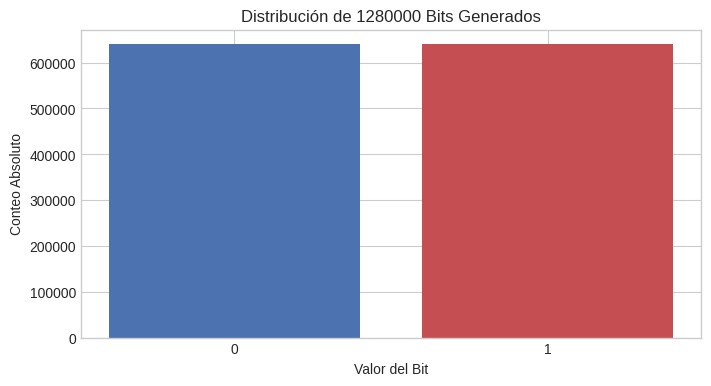


Media de los bits: 0.4999 (valor ideal: 0.5)


In [2]:
# Calcular el número total de bits a generar
n_total_bits = p.N_sym * p.N * p.mu

print(f"Parámetros de la simulación:")
print(f"  - Símbolos OFDM a simular (N_sym): {p.N_sym}")
print(f"  - Subportadoras por símbolo (N): {p.N}")
print(f"  - Bits por símbolo de constelación (mu): {p.mu}")
print(f"--------------------------------------------------")
print(f"Total de bits a generar: {n_total_bits}")

# Generar la secuencia de bits aleatoria usando el RNG de params
bits_tx = p.RNG.integers(low=0, high=2, size=n_total_bits)

# --- Verificación ---
print(f"\nDimensión del vector de bits generado: {bits_tx.shape}")
print(f"Primeros 20 bits generados: {bits_tx[:20]}")

# Comprobar que la distribución es aproximadamente uniforme
plt.figure(figsize=(8, 4))
counts = np.bincount(bits_tx)
plt.bar([0, 1], counts, color=['#4c72b0', '#c44e52'])
plt.title(f'Distribución de {n_total_bits} Bits Generados')
plt.xticks([0, 1])
plt.xlabel('Valor del Bit')
plt.ylabel('Conteo Absoluto')
plt.show()

media_bits = np.mean(bits_tx)
print(f"\nMedia de los bits: {media_bits:.4f} (valor ideal: 0.5)")
assert 0.49 < media_bits < 0.51, "La distribución de bits no parece uniforme."


### Bloque 2: Mapeo de Bits a Símbolos de Constelación (Modulación Digital)

En el bloque anterior, generamos una larga secuencia de unos y ceros. Sin embargo, estos bits son una representación abstracta de la información. Para poder transmitirlos a través de un medio físico (como el aire o un cable), necesitamos convertirlos en una **señal analógica**. Este proceso se llama **modulación**.

La modulación consiste en variar una propiedad de una onda portadora (como su amplitud, fase o frecuencia) de acuerdo con la información que queremos enviar. En OFDM, en lugar de modular una sola portadora, modulamos `N` subportadoras simultáneamente. Pero antes de eso, debemos decidir qué señal modulará cada una de estas subportadoras.

#### ¿Qué es un Símbolo de Constelación?

En lugar de enviar un bit a la vez, los sistemas de comunicación modernos agrupan varios bits para formar un **símbolo**. Un símbolo es un estado único de la señal que representa un grupo específico de bits. La colección de todos los símbolos posibles se llama **constelación**.

Visualizamos esta constelación en un **diagrama de constelación**, que es un gráfico en el plano complejo (también conocido como plano I/Q, por "In-phase" y "Quadrature"). Cada punto en este diagrama representa un símbolo único, definido por una amplitud (su distancia al origen) y una fase (su ángulo con el eje real).

#### Modulación por Desplazamiento de Fase en Cuadratura (QPSK)

Para nuestra simulación, utilizaremos **QPSK (Quadrature Phase Shift Keying)**, una de las formas más comunes de modulación digital.

*   **Quaternary (Cuaternaria):** Significa que hay 4 símbolos posibles en la constelación. Como $2^2 = 4$, cada símbolo QPSK puede representar un grupo de **2 bits** (`mu = 2`).
*   **Phase Shift (Desplazamiento de Fase):** La información se codifica únicamente en la fase de la onda portadora. En QPSK, se utilizan cuatro fases distintas, separadas por 90 grados (45°, 135°, 225°, 315°). La amplitud de todos los símbolos es la misma.
*   **Keying (Manipulación):** Es el proceso de cambiar (o "manipular") la fase de la portadora según el grupo de bits de entrada.

#### El Proceso de Mapeo y la Codificación Gray

El mapeo es el proceso de asignar cada posible grupo de bits a un punto específico de la constelación. Para QPSK, asignamos cada par de bits a uno de los cuatro puntos. Una asignación inteligente es crucial, y para ello se utiliza la **codificación Gray**.

**¿Por qué es importante la codificación Gray?**
En un canal real, el ruido puede hacer que el receptor se equivoque y confunda un símbolo con uno adyacente en la constelación. Con la codificación Gray, los símbolos adyacentes **difieren en un solo bit**. Esto significa que el error más probable (confundir un símbolo con su vecino) resultará en **un solo bit erróneo** en lugar de dos, mejorando significativamente el rendimiento del sistema (la BER).

Nuestra tabla de mapeo QPSK con codificación Gray es la siguiente:

| Par de Bits (b₁, b₂) | Símbolo Complejo (X)               | Coordenadas (Real, Imag) |
| :------------------: | :--------------------------------: | :-----------------------: |
|          10          | $\frac{1}{\sqrt{2}} (1 - j)$        |         (+1, -1)          |
|          11          | $\frac{1}{\sqrt{2}} (-1 - j)$       |         (-1, -1)          |
|          01          | $\frac{1}{\sqrt{2}} (-1 + j)$       |         (-1, +1)          |
|          00          | $\frac{1}{\sqrt{2}} (1 + j)$        |         (+1, +1)          |

**Fórmula de Mapeo y Normalización:**
Este mapeo se puede implementar eficientemente con una única fórmula matemática. Para un par de bits $(b_1, b_2)$:

$$ X = \frac{(2b_1 - 1) + j(2b_2 - 1)}{\sqrt{2}} $$

*   El término `(2b - 1)` es un truco elegante para convertir un bit `0` en `-1` y un bit `1` en `+1`.
*   El factor $\frac{1}{\sqrt{2}}$ se llama **factor de normalización**. Se utiliza para asegurar que la **energía promedio por símbolo ($E_s$) sea igual a 1**. Esto es fundamental para que los cálculos de relación señal-ruido (SNR) y la comparación de rendimiento entre diferentes esquemas de modulación sean justos y consistentes. La energía de un símbolo complejo $s = a+jb$ es $|s|^2 = a^2+b^2$. Para nuestro símbolo $(1+j)/\sqrt{2}$, la energía es $(\frac{1}{\sqrt{2}})^2 + (\frac{1}{\sqrt{2}})^2 = \frac{1}{2} + \frac{1}{2} = 1$. Como todos los símbolos tienen la misma energía, la energía promedio es 1.

In [3]:
# Paso 1: Reformatear la secuencia de bits en grupos de 'mu' bits.
# La dimensión resultante será (N_total_de_simbolos, mu).
bits_reshaped = bits_tx.reshape(-1, p.mu)

# --- Verificación ---
print(f"Dimensiones de la matriz de bits agrupados: {bits_reshaped.shape}")
print(f"Número de grupos de bits (símbolos a mapear): {bits_reshaped.shape[0]}")
print(f"Bits por grupo (mu): {bits_reshaped.shape[1]}")
print("\nPrimeros 5 grupos de bits:")
print(bits_reshaped[:5])

Dimensiones de la matriz de bits agrupados: (640000, 2)
Número de grupos de bits (símbolos a mapear): 640000
Bits por grupo (mu): 2

Primeros 5 grupos de bits:
[[0 1]
 [1 0]
 [0 1]
 [0 1]
 [0 0]]


In [ ]:
# Paso 2: Mapear cada grupo de bits a un símbolo complejo.
# Usamos la fórmula matemática para eficiencia, aplicando la operación a toda la matriz.

# (2 * b - 1) convierte {0, 1} a {-1, 1}
# La primera columna (bits b1) va a la parte real.
# La segunda columna (bits b2) va a la parte imaginaria.
symbols_complex = ( (2 * bits_reshaped[:, 0] - 1) + 1j * (2 * bits_reshaped[:, 1] - 1) )
# si bit = 0 -> 2 x 0 - 1 = -1
# si bit = 1 -> 2 x 1 - 1 = +1

# Paso 3: Normalizar los símbolos para que la energía promedio sea 1.
symbols_complex /= np.sqrt(2)

# --- Verificación ---
print(f"Dimensiones del vector de símbolos complejos: {symbols_complex.shape}")
print("\nPrimeros 5 símbolos complejos generados (redondeados):")
print(np.round(symbols_complex[:5], 3))

Dimensiones del vector de símbolos complejos: (640000,)

Primeros 5 símbolos complejos generados (redondeados):
[-0.707+0.707j  0.707-0.707j -0.707+0.707j -0.707+0.707j -0.707-0.707j]


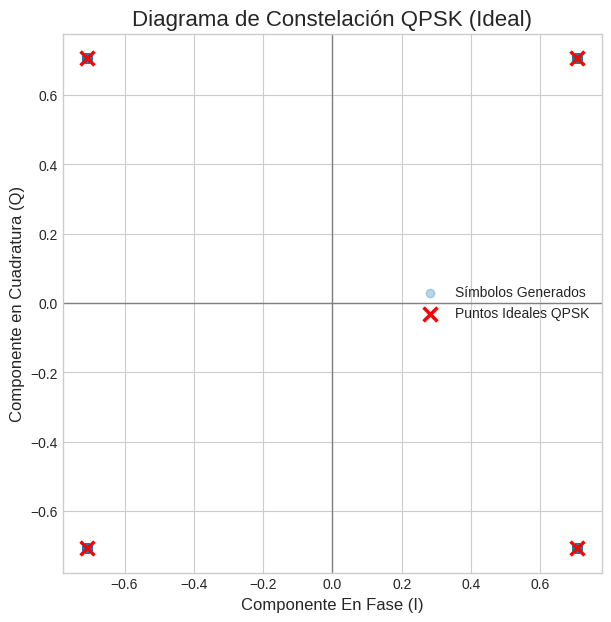

In [ ]:
# Crear un scatter plot de la constelación ideal
# Estos son los 4 puntos que deberían existir
ideal_constellation = ( (2*np.array([0,0,1,1]) - 1) + 1j*(2*np.array([0,1,1,0]) - 1) ) / np.sqrt(2)
# if 0 => -1
# if 1 => +1

plt.figure(figsize=(7, 7))

# Graficamos una muestra de los símbolos generados para no sobrecargar el gráfico
# Usamos alpha para ver la densidad de puntos
plt.scatter(np.real(symbols_complex[:5000]), np.imag(symbols_complex[:5000]), 
            alpha=0.3, label='Símbolos Generados')

# Superponemos los puntos ideales para verificar
plt.scatter(np.real(ideal_constellation), np.imag(ideal_constellation), 
            color='red', marker='x', s=100, linewidth=2.5, label='Puntos Ideales QPSK')

plt.title('Diagrama de Constelación QPSK (Ideal)', fontsize=16)
plt.xlabel('Componente En Fase (I)', fontsize=12)
plt.ylabel('Componente en Cuadratura (Q)', fontsize=12)
plt.axhline(0, color='grey', lw=1)
plt.axvline(0, color='grey', lw=1)
plt.grid(True)
plt.legend()
plt.axis('square') # Asegura que los ejes tengan la misma escala
plt.show()

### La Energía del Símbolo

Un concepto fundamental en comunicaciones digitales es la **energía por símbolo**, denotada como $E_s$. Físicamente, representa la energía que se gasta para transmitir un único símbolo a través del canal durante su intervalo de tiempo.

Matemáticamente, para un símbolo complejo $s = I + jQ$, su energía se calcula como el cuadrado de su magnitud (o módulo):

$$ E_s = |s|^2 = (\sqrt{I^2 + Q^2})^2 = I^2 + Q^2 $$

En un diagrama de constelación, esto es simplemente el cuadrado de la distancia del punto al origen.

In [ ]:
# Calcular la energía promedio de todos los símbolos generados
# La energía de un símbolo 's' es |s|^2
average_energy = np.mean(np.abs(symbols_complex)**2) # .mean saca el valor medio de las energias

print(f"Energía promedio por símbolo calculada: {average_energy:.4f}")
print(f"Energía promedio por símbolo esperada: {p.Es}")

# Usamos np.isclose para comparar números de punto flotante de forma segura
assert np.isclose(average_energy, p.Es), "La normalización de la energía no es correcta."

print("\n¡Verificación superada! La constelación está correctamente generada y normalizada.")

Energía promedio por símbolo calculada: 1.0000
Energía promedio por símbolo esperada: 1.0

¡Verificación superada! La constelación está correctamente generada y normalizada.
